In [29]:
## checking the dataset properties

import pandas as pd

df= pd.read_csv("../Dataset/sample_tickets_dataset.csv")
print(df.shape)
print(df.columns.tolist)
print(df.dtypes)

(8469, 17)
<bound method IndexOpsMixin.tolist of Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating'],
      dtype='str')>
Ticket ID                         int64
Customer Name                       str
Customer Email                      str
Customer Age                      int64
Customer Gender                     str
Product Purchased                   str
Date of Purchase                    str
Ticket Type                         str
Ticket Subject                      str
Ticket Description                  str
Ticket Status                       str
Resolution                          str
Ticket Priority                     str
Ticket Channel                      str
Firs

In [30]:
for columns in df.columns:
    print(df[columns].value_counts())

Ticket ID
1       1
2       1
3       1
4       1
5       1
       ..
8465    1
8466    1
8467    1
8468    1
8469    1
Name: count, Length: 8469, dtype: int64
Customer Name
Michael Garcia       5
James Smith          5
David Smith          4
Steven Johnson       4
Christopher Jones    4
                    ..
Trevor Perry         1
Shelby Douglas       1
Brandon Walsh        1
Michelle Kelley      1
Steven Davis MD      1
Name: count, Length: 8028, dtype: int64
Customer Email
asmith@example.com        4
bsmith@example.com        4
drodriguez@example.com    3
asmith@example.org        3
hsmith@example.org        3
                         ..
adam28@example.net        1
russell68@example.com     1
ashley83@example.org      1
fpowell@example.org       1
lori20@example.net        1
Name: count, Length: 8320, dtype: int64
Customer Age
52    186
56    182
27    180
24    180
34    177
59    177
44    173
20    173
48    172
63    171
33    171
46    171
42    170
19    169
69    169
67    1

## what we have learnt from the initial raw dataset

1. ticket type will be the main classification target, based on what type of theticket is talking about, we will predict the priority of the ticket

2. the ticket description has one main issue of having {product purchased} and {error_message} which are unfilled parameters which makes this column very weak by itelse. So we combine it with ticket subject to me used more reliablely

3. we can remove unneccessary columns like ticket id, customer name, customer emal, age, gender etc

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [33]:
print(df.shape)

(8469, 17)


In [34]:
## checking null values
df.isnull().sum()

Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Subject                     0
Ticket Description                 0
Ticket Status                      0
Resolution                      5700
Ticket Priority                    0
Ticket Channel                     0
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5700
dtype: int64

In [35]:
## dropping unneccessary columns
print(df.columns.tolist())

['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age', 'Customer Gender', 'Product Purchased', 'Date of Purchase', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Resolution', 'Ticket Priority', 'Ticket Channel', 'First Response Time', 'Time to Resolution', 'Customer Satisfaction Rating']


In [36]:
df = df.drop(columns=['Ticket ID','Customer Name', 'Customer Email', 'Customer Age', 'Customer Gender',
               'Date of Purchase','First Response Time','Time to Resolution','Resolution', 
               "Customer Satisfaction Rating"],errors='ignore')

In [37]:
df.head()

,Product Purchased,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Ticket Priority,Ticket Channel
0,GoPro Hero,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,Critical,Social media
1,LG Smart TV,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,Critical,Chat
2,Dell XPS,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Low,Social media
3,Microsoft Office,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Low,Social media
4,Autodesk AutoCAD,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,Low,Email


In [38]:
## checking null values again
df.isnull().sum()

Product Purchased     0
Ticket Type           0
Ticket Subject        0
Ticket Description    0
Ticket Status         0
Ticket Priority       0
Ticket Channel        0
dtype: int64

for ticket types count: 

Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64

for ticket priority count: 

Ticket Priority
Medium      2192
Critical    2129
High        2085
Low         2063
Name: count, dtype: int64


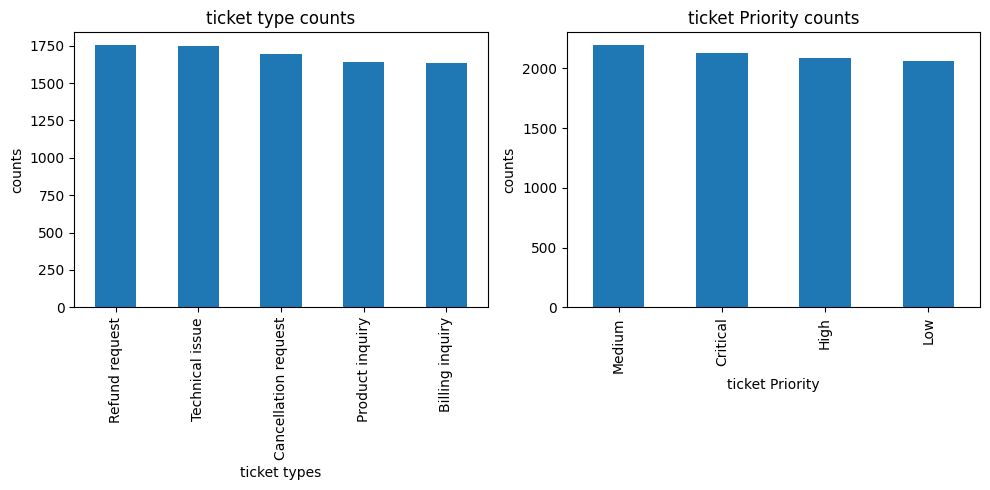

In [59]:
print("for ticket types count: \n")
print(df['Ticket Type'].value_counts())

print("\nfor ticket priority count: \n")
print(df['Ticket Priority'].value_counts())
ticket_type_counts = df['Ticket Type'].value_counts()
ticket_priority_counts = df['Ticket Priority'].value_counts()

figure, axes = plt.subplots(1,2, figsize=(10,5))

ticket_type_counts.plot(kind='bar',ax=axes[0])
axes[0].set_xlabel("ticket types")
axes[0].set_title("ticket type counts")
axes[0].set_ylabel("counts")

ticket_priority_counts.plot(kind='bar',ax=axes[1])
axes[1].set_xlabel("ticket Priority")
axes[1].set_title("ticket Priority counts")
axes[1].set_ylabel("counts")



plt.tight_layout()
plt.show()

### insight from the graphs
all the main outputs seem to be pretty balanced which will help in a better model performance and accuracy

In [73]:
## checking the correlation between priority and type using heatmap
print(pd.crosstab(df['Ticket Type'], df['Ticket Priority']))
# this crosstab shows that for each type of ticket how many tickets are criticla, high, low and medium

Ticket Priority       Critical  High  Low  Medium
Ticket Type                                      
Billing inquiry            420   382  398     434
Cancellation request       423   398  414     460
Product inquiry            403   399  398     441
Refund request             444   448  440     420
Technical issue            439   458  413     437


<Axes: xlabel='Ticket Priority', ylabel='Ticket Type'>

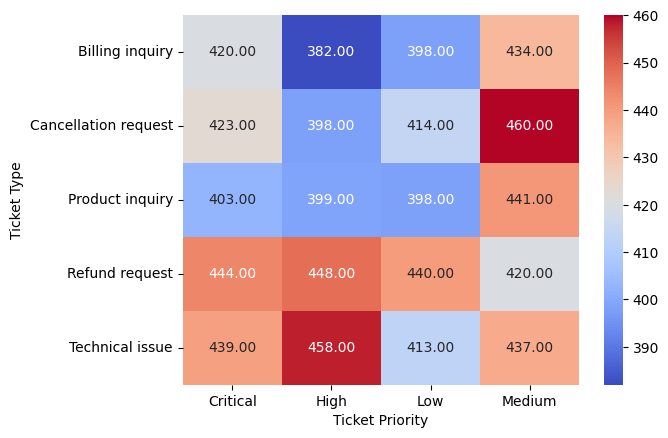

In [74]:
sns.heatmap(pd.crosstab(df['Ticket Type'], df['Ticket Priority']), annot=True,fmt=".2f", cmap="coolwarm")

### insight from heatmap
Ticket Type and Ticket Priority show near-uniform distribution across all combinations (range: 390-460 out of 8,469 tickets). No ticket type is
strongly associated with a specific priority level, suggesting priority is determined by factors beyond ticket type alone — likely ticket description content and urgency keywords.

This means our model must rely heavily on text features rather than categorical features to predict priority.

Ticket Channel
Email           2143
Phone           2132
Social media    2121
Chat            2073
Name: count, dtype: int64


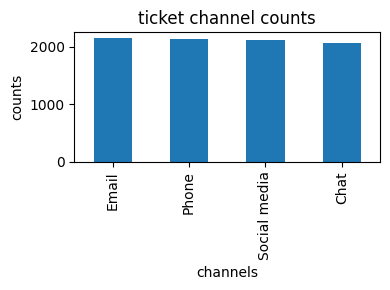

In [80]:
## observing ticket channel distribution
# here we will check choch channel gets most tickets

print(df["Ticket Channel"].value_counts())
ticket_channel_counts = df["Ticket Channel"].value_counts()

plt.figure(figsize=(4,3))

ticket_channel_counts.plot(kind="bar")
plt.title("ticket channel counts")
plt.xlabel("channels")
plt.ylabel("counts")
plt.tight_layout()

plt.show()

### insight from the channel counts
all the tickets are coming to be very uniform across all the different types of channels.
no channel is has much higher ticket counts than other
this mean that priority can not be determined by channel alone

In [83]:
## obsering text length distribution
df['description_length'] = df['Ticket Description'].str.len()
df.head()

,Product Purchased,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Ticket Priority,Ticket Channel,description_length
0,GoPro Hero,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,Critical,Social media,284
1,LG Smart TV,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,Critical,Chat,282
2,Dell XPS,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Low,Social media,275
3,Microsoft Office,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Low,Social media,262
4,Autodesk AutoCAD,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,Low,Email,333


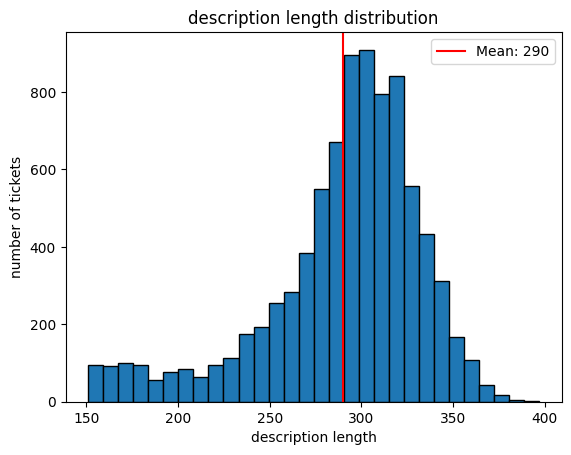

In [89]:
# plotting the histogram
plt.hist(df['description_length'], bins=30, edgecolor='black')
plt.xlabel('description length')
plt.ylabel('number of tickets')
plt.title("description length distribution")
plt.axvline(df['description_length'].mean(), color='red', label=f"Mean: {df['description_length'].mean():.0f}")
##axvline = draws a vertical line at mean
plt.legend()
plt.show()

### insights from description length distribution
- most of the tickets have characters from about 270 to 330 with the maximumn tickets being at 320 characters length
- there might be some description that might be too brief for the model to classify well

- - Description lengths follow a roughly normal distribution 
  centered around 300-320 characters, indicating consistent 
  ticket quality across the dataset. No extreme outliers 
  that would require special handling.